# V. Raster Analysis


**Растровые пространственные данные** — это способ представления географической информации в виде регулярной сетки (матрицы) одинаковых по размеру ячеек — пикселей. Каждая ячейка соответствует определённой территории и содержит числовое значение (или набор значений), например: высоту, температуру, интенсивность отражённого излучения и др.

Растровый формат особенно удобен для данных, которые **непрерывно изменяются в пространстве**, то есть описывают поверхности: рельеф, осадки, температуру, влажность почвы, и др.

Размер пикселя определяет **пространственное разрешение** данных: чем он меньше, тем подробнее растр описывает территорию.

В этом разделе мы разберём несколько примеров растровых пространственных данных и посмотрим, как работать с ними в Python


Импортируем библиотеки


In [192]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import matplotlib.pyplot as plt
import numpy as np
import rasterio

## 1. Знакомство с растровым форматом


### 1.1 Исследование данных


Экспортируем данные о населении для всей России c сайта [World Pop](https://www.worldpop.org) (опционально, набор для работы уже лежит в директории)


In [193]:
#Можно выгрузить данные с портала World Pop (300 Mb + )

# # Ссылка на данные WorldPop
# url = "https://data.worldpop.org/GIS/Population/Global_2000_2020_Constrained/2020/BSGM/RUS/rus_ppp_2020_constrained.tif"

# # Имя файла для сохранения
# output_file = "worldpop_russia_2020.tif"

# # Скачивание файла
# response = requests.get(url, stream=True)

# if response.status_code == 200:
#     with open(output_file, "wb") as file:
#         for chunk in response.iter_content(chunk_size=1024):
#             file.write(chunk)
#     print(f"File saved as {output_file}")
# else:
#     print("Failed to download file. Status code:", response.status_code)


Откроем заранее экспортированный файл по Тульской области (сокращённая версия данных, подготовленная для примера)

Сделаем это с помощью библиотеки `rasterio` для открытия растрового файла.

Также извлечём ключевые метаданные слоя:

- **CRS (Coordinate Reference System)** — система координат,
- **границы растра (bounds)** — пространственный охват данных,
- **пространственное разрешение (resolution)** — размер пикселя.


In [194]:
output_file = './data/tula_region_population.tif'


with rasterio.open(output_file) as dataset:
    print("CRS:", dataset.crs)
    print("Bounds:", dataset.bounds)
    print("Resolution:", dataset.res)


CRS: EPSG:4326
Bounds: BoundingBox(left=35.89855540000002, bottom=52.94600317428952, right=38.95188872112002, top=54.85183649999999)
Resolution: (0.00083333333, 0.0008333333300002048)


Визуализируем данные на карте


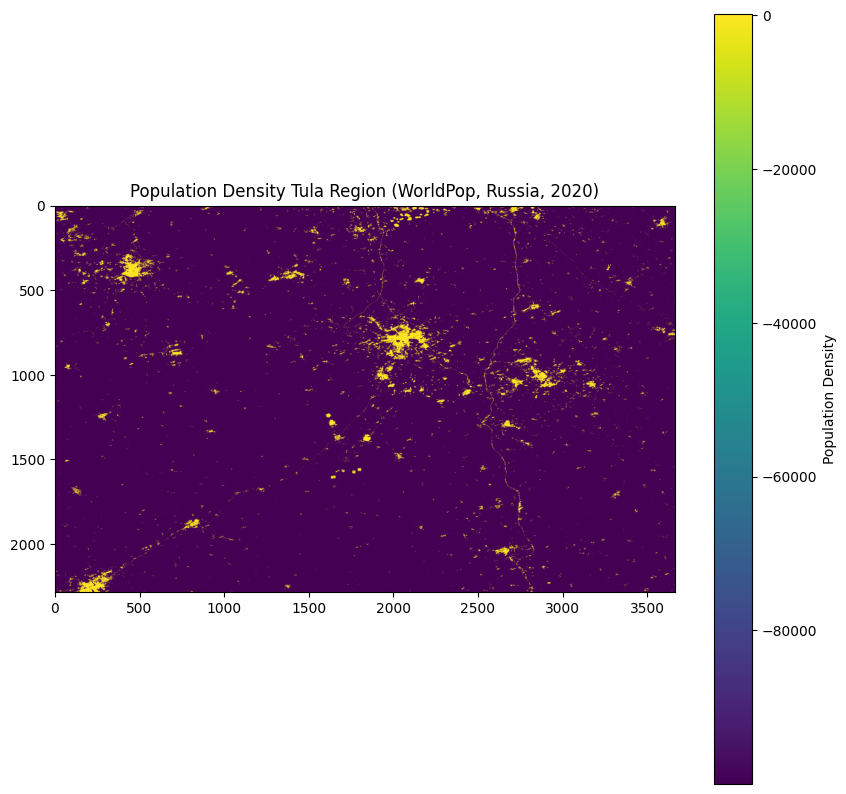

In [195]:
with rasterio.open(output_file) as src:
    data = src.read(1)  

    plt.figure(figsize=(10, 10))
    plt.imshow(data, cmap='viridis') 
    plt.colorbar(label="Population Density") 
    plt.title("Population Density Tula Region (WorldPop, Russia, 2020)")
    plt.show()


Откуда взялись минусовые значения? Давайте разбираться, но перед этим посмотрим на статистику значений в пикселях


In [196]:
with rasterio.open(output_file) as src:
    data = src.read(1) 
    # Выводим статистику
    print("Min value:", np.min(data))
    print("Max value:", np.max(data))
    print("Mean value:", np.mean(data))

Min value: -99999.0
Max value: 161.41058
Mean value: -97470.07


Минимальное значение растра равно `-99999` - это точно не значения плотности населения.

В растровых данных подобные экстремальные отрицательные числа чаще всего используются как **служебные значения (_NoData_)**, обозначающие отсутствие информации в пикселе


Восползуемся masked array от rasterio, чтобы исключить из рассмотрения ячейки, где данные отсутствуют


In [197]:
with rasterio.open(output_file) as src:
    data = src.read(1, masked=True)  # NoData будет маской

print("Min:", data.min())
print("Max:", data.max())
print("Mean:", data.mean())

Min: 0.66187334
Max: 161.41058
Mean: 11.286797359094276


И посмотрим на карту также без отсутсвующих значений


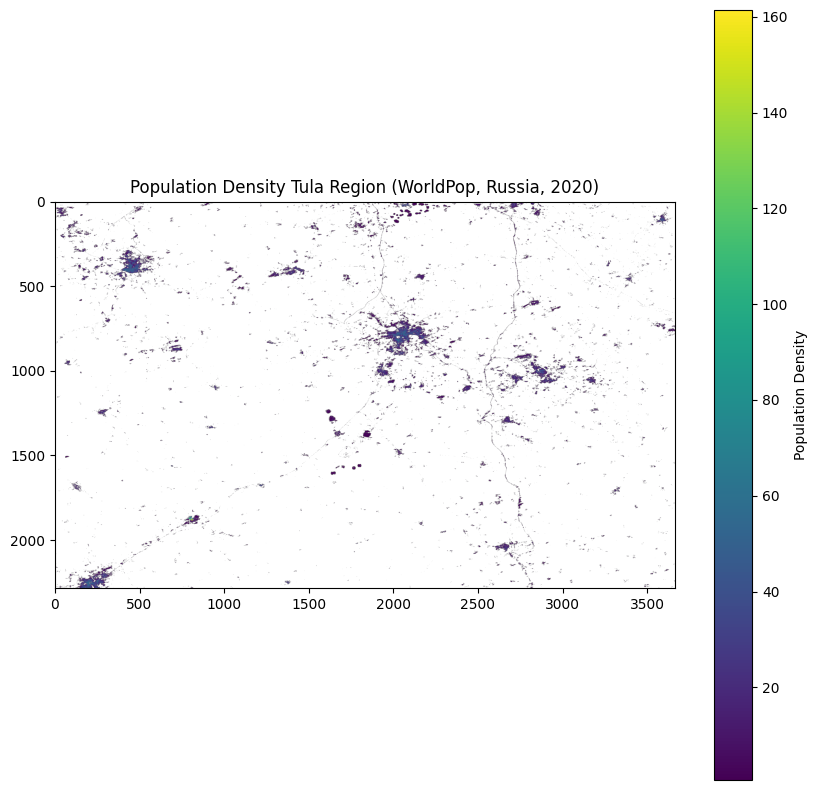

In [198]:
with rasterio.open(output_file) as src:
    data = src.read(1, masked=True)

plt.figure(figsize=(10, 10))
plt.imshow(data, cmap="viridis")
plt.colorbar(label="Population Density")
plt.title("Population Density Tula Region (WorldPop, Russia, 2020)")
plt.show()


### 1.2 Обрезка растра на основе векторного слоя


Давайте обрежем данные для города Тула


Скачаем границы Тулы из osm (с помощью библиотеки osmnx), чтобы по ним обрезать растр


In [199]:
area_name = "Тула, Россия"

gdf_borders = ox.geocode_to_gdf(area_name)

gdf_borders.explore(tiles='cartodbpositron')

Обрезаем данные о численности населения по границе Тулы (важно, чтобы оба набора данных были в одной системе координат)


In [200]:
import rasterio
from rasterio.mask import mask
import json

# Убедимся, что CRS совпадает
with rasterio.open(output_file) as src:
    
    # Если CRS различаются — перепроецируем границы
    if gdf_borders.crs != src.crs:
        gdf_borders = gdf_borders.to_crs(src.crs)
    
    # Преобразуем геометрию в формат GeoJSON
    geometries = [json.loads(gdf_borders.to_json())['features'][0]['geometry']]
    
    # Обрезка по точной геометрии
    out_image, out_transform = mask(src, geometries, crop=True)
    
    # Обновляем профиль
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

# Сохраняем результат
with rasterio.open("./data/tula_cropped_population.tif", "w", **out_meta) as dest:
    dest.write(out_image)


Получаем информацию о сохраненных данных


In [201]:
# Открытие файла
file_path = "./data/tula_cropped_population.tif"

with rasterio.open(file_path) as src:
    # Вывод основной информации о растре
    print("CRS:", src.crs)  # Система координат
    print("Bounds:", src.bounds)  # Границы растра
    print("Width, Height:", src.width, src.height)  # Размер растра
    print("Number of bands:", src.count)  # Количество слоев
    print("Data type:", src.dtypes)  # Тип данных
    print("Transform:", src.transform)  # Аффинная трансформация


CRS: EPSG:4326
Bounds: BoundingBox(left=37.49522206028002, bottom=54.061836503159796, right=37.741888725960024, top=54.300169835539855)
Width, Height: 296 286
Number of bands: 1
Data type: ('float32',)
Transform: | 0.00, 0.00, 37.50|
| 0.00,-0.00, 54.30|
| 0.00, 0.00, 1.00|


Обратите внимание, что слой находится в географической системе координат (EPSG:4326).
Это означает, что размер пикселя выражен в градусах, а не в метрах.

Получаем информацию о размере одного пикселя


In [202]:
with rasterio.open(file_path) as src:
    transform = src.transform  # Аффинная трансформация растра

    # Извлечение размеров пикселя
    pixel_width = transform.a  # Размер пикселя по оси X
    pixel_height = -transform.e  # Размер пикселя по оси Y (берем с минусом, так как Y направлен вниз в системе координат)

    print(f"Pixel Width: {pixel_width} units")
    print(f"Pixel Height: {pixel_height} units")


Pixel Width: 0.00083333333 units
Pixel Height: 0.0008333333300002048 units


### 1.3 Перепроецирование растра


Сейчас наш растровый слой в географической системе координат. Перепроецируем растр в подходящую UTM зону, чтобы можно былло дальше с ним работать в метрической системе


Рассчитываем подходяющую UTM-зону на основе слоя с границами выбранной области


In [203]:
target_crs = gdf_borders.estimate_utm_crs()

Перепроецируем


In [204]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

output_file_cropped = "./data/tula_cropped_reprojected.tif"

with rasterio.open(file_path) as src:
    transform, width, height = calculate_default_transform(src.crs, target_crs, src.width, src.height, *src.bounds)
    profile = src.profile
    profile.update({
        'crs': target_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(output_file_cropped, 'w', **profile) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=target_crs,
                resampling=Resampling.nearest
            )


И еще раз посмотрим на информацию о размере одного пикселя


In [205]:
with rasterio.open(output_file_cropped) as src:
    transform = src.transform 

    # Извлечение размеров пикселя
    pixel_width = transform.a  # Размер пикселя по оси X
    pixel_height = -transform.e  # Размер пикселя по оси Y (берем с минусом, так как Y направлен вниз в системе координат)

    print(f"Pixel Width: {pixel_width} units")
    print(f"Pixel Height: {pixel_height} units")


Pixel Width: 75.37731228269381 units
Pixel Height: 75.37731228269381 units


Теперь размер пикселя выражен в метрах.
Это делает возможным корректный расчёт площадей и плотности на следующих этапах


Визуализируем данные на карте


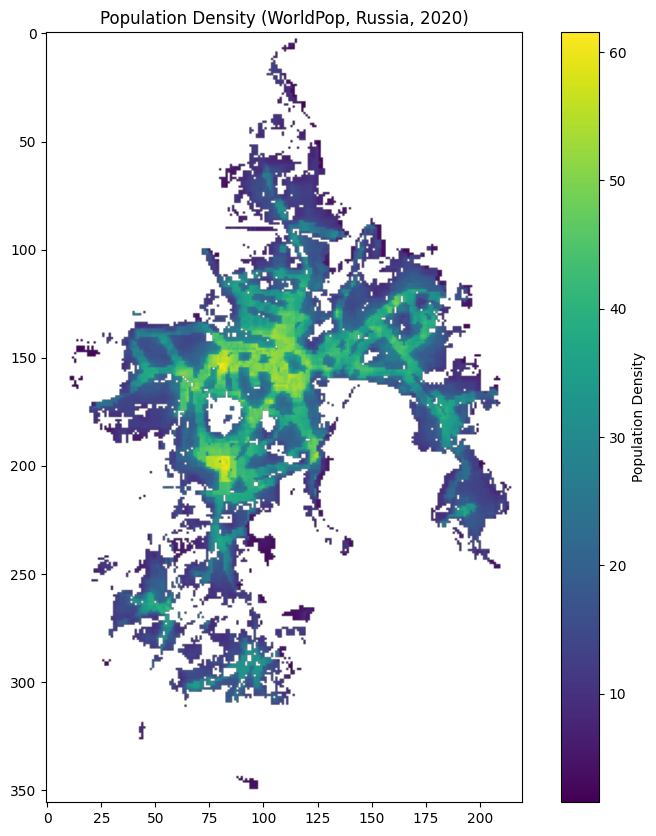

In [206]:
with rasterio.open(output_file_cropped) as src:
    data = src.read(1, masked=True)  

    plt.figure(figsize=(10, 10))
    plt.imshow(data, cmap='viridis') 
    plt.colorbar(label="Population Density")  
    plt.title("Population Density (WorldPop, Russia, 2020)")
    plt.show()


## 2.Зональная статистика


**Зональная статистика** — это метод пространственного анализа, позволяющий агрегировать значения растрового слоя в пределах заданных векторных объектов (зон). Иными словами, для каждой зоны (например, ячейки сетки или административной границы) рассчитываются статистические показатели значений пикселей, попадающих внутрь неё.

Зональная статистика позволяет перейти от непрерывной растровой поверхности (распределения населения) к агрегированным показателям по пространственным единицам


В данном разделе мы познакомимся с методом зональной статистики на основе агрегирования значений растрового слоя с численностью населения по ячейкам регулярной сетки.


### Расчет плотности населения по ячейкам регулярной сетки на основе данных World Pop


Создаём ячейки регулярной сетки для Тулы


In [207]:
from shapely.geometry import box

def create_regular_grid(gdf, square_size):
    # Если набор в географических координатах, перепроецируем в UTM
    utm_crs = gdf.estimate_utm_crs()
    gdf_utm = gdf.to_crs(utm_crs)
    # Получаем границы (bounding box) области
    minX, minY, maxX, maxY = gdf_utm.total_bounds
    grid_cells = []
    x, y = minX, minY
    # Двойной цикл: заполняем прямоугольник границ квадратами заданного размера
    while y <= maxY:
        while x <= maxX:
            grid_cells.append(box(x, y, x + square_size, y + square_size))
            x += square_size # двигаемся по X
        x = minX             # возврат к началу по X
        y += square_size     # двигаемся по Y (следующий ряд)
    # Формируем GeoDataFrame
    fishnet = gpd.GeoDataFrame(geometry=grid_cells, crs=utm_crs)
    return fishnet


# Строим сетку с шагом 1000 м
fishnet = create_regular_grid(gdf_borders, square_size=1000)
print(f"Создано ячеек: {len(fishnet)}")


fishnet.explore(tiles='cartodbpositron')

Создано ячеек: 459


Проверим, совпадают ли системы координат ячеек и растра (зональная статистика корректна только при совпадении систем координат)


In [208]:
print(fishnet.crs)
print(target_crs)

EPSG:32637
EPSG:32637


Рассчитываем зональную статистику


In [209]:
import rasterstats as rs

# Рассчитываем зональную статистику (сумма значений растра для каждого полигона)
stats = rs.zonal_stats(fishnet, output_file_cropped, stats="sum", geojson_out=True)

# Преобразуем результат в GeoDataFrame
gdf_stats = gpd.GeoDataFrame.from_features(stats, crs=target_crs)

# Теперь у вас есть GeoDataFrame с дополнительной колонкой, содержащей сумму значений для каждого полигона
gdf_stats.head()


,geometry,sum
0,"POLYGON ((402784.669 5991296.012, 402784.669 5...",NaN
1,"POLYGON ((403784.669 5991296.012, 403784.669 5...",NaN
2,"POLYGON ((404784.669 5991296.012, 404784.669 5...",NaN
3,"POLYGON ((405784.669 5991296.012, 405784.669 5...",NaN
4,"POLYGON ((406784.669 5991296.012, 406784.669 5...",NaN


Вычисляем плотность населения (человек на км²): сумма населенеия в ячейке, разделённая на её площадь(в км²).


In [210]:
gdf_stats['density'] = gdf_stats['sum']/(gdf_stats.geometry.area/1000000)

Смотрим на результат


In [211]:
gdf_stats.explore(column='density', tiles='cartodbpositron')

## 3. Сравнение разных оценок плотности населения


Существует несколько подходов к оценке численности населения на локальном уровне. Помимо модельных глобальных продуктов, таких как WorldPop, для городов России применяется метод оценки численности населения на основе данных о жилой площади в многоквартирных домах (МКД).

Данный подход основан на предположении о средней обеспеченности населения жилой площадью: зная суммарную площадь жилых помещений в пределах территории, можно рассчитать ориентировочную численность проживающих. Подробнее с методологией расчёта можно ознакомиться по [ссылке](https://bella-mir.github.io/spatialPython_hse25/chapters/realWorldTasks/task1.html).

В данном разделе мы сравним результаты, полученные на основе данных МКД, с оценками WorldPop и проанализируем возможные различия между этими подходами.


### 3.1 Расчет плотности населения на основе данных о жилой площади в МКД


Читаем геокодированные данные МКД по Туле


In [212]:
mkd_df = pd.read_csv('data/tula_mkd_geocoded.csv')

Создадим на основе координат GeoDataFrame и посмотрим на результат


In [213]:
mkd_gdf = gpd.GeoDataFrame(mkd_df, geometry=gpd.points_from_xy(mkd_df.lon, mkd_df.lat), crs="EPSG:4326")

#mkd_gdf.explore(tiles='cartodbpositron')

На основе средней обеспеченности населения квадратными метрами в Тульской области (по данным Росстата), рассчитаем кол-во человек, проживающих в каждом доме


In [214]:
# Приводим жилую площадь к числовому формату:
# заменяем запятую на точку и конвертируем в float
mkd_gdf["area_residential"] = (
    mkd_gdf["area_residential"]
        .str.replace(",", ".", regex=False)
)

mkd_gdf["area_residential"] = pd.to_numeric(
    mkd_gdf["area_residential"],
    errors="coerce"   # некорректные значения -> NaN
)

# Оценка численности населения (28 м² на человека - приблизительное число)
mkd_gdf['estimated_population'] = mkd_gdf['area_residential'] / 28

# Смотрим на результат
mkd_gdf.head()

,id,region_id,area_id,city_id,street_id,shortname_region,formalname_region,shortname_area,formalname_area,shortname_city,...,sewerage_type,sewerage_cesspools_volume,gas_type,ventilation_type,firefighting_type,drainage_type,lon,lat,geometry,estimated_population
0,9375487,d028ec4f-f6da-4843-ada6-b68b3e0efa3d,NaN,b2601b18-6da2-4789-9fbe-800dde06a2bb,NaN,обл,Тульская,NaN,NaN,г,...,Не заполнено,NaN,Не заполнено,Не заполнено,Не заполнено,Не заполнено,37.57685,54.17845,POINT (37.57685 54.17845),NaN
1,8200202,d028ec4f-f6da-4843-ada6-b68b3e0efa3d,NaN,b2601b18-6da2-4789-9fbe-800dde06a2bb,NaN,обл,Тульская,NaN,NaN,г,...,Центральное,"0,00",Отсутствует,Приточно-вытяжная вентиляция,Отсутствует,Отсутствует,37.61874,54.19407,POINT (37.61874 54.19407),8.703571
2,8200199,d028ec4f-f6da-4843-ada6-b68b3e0efa3d,NaN,b2601b18-6da2-4789-9fbe-800dde06a2bb,NaN,обл,Тульская,NaN,NaN,г,...,Центральное,"0,00",Отсутствует,Приточно-вытяжная вентиляция,Отсутствует,Отсутствует,37.61874,54.19407,POINT (37.61874 54.19407),8.410714
3,8200197,d028ec4f-f6da-4843-ada6-b68b3e0efa3d,NaN,b2601b18-6da2-4789-9fbe-800dde06a2bb,NaN,обл,Тульская,NaN,NaN,г,...,Центральное,"0,00",Отсутствует,Приточно-вытяжная вентиляция,Отсутствует,Наружные водостоки,37.61874,54.19407,POINT (37.61874 54.19407),9.517857
4,8200213,d028ec4f-f6da-4843-ada6-b68b3e0efa3d,NaN,b2601b18-6da2-4789-9fbe-800dde06a2bb,NaN,обл,Тульская,NaN,NaN,г,...,Центральное,"0,00",Отсутствует,Вытяжная вентиляция,Отсутствует,Отсутствует,37.61874,54.19407,POINT (37.61874 54.19407),9.690357


Пересечем данные с уже использованной выше сеткой регулярных ячеек и рассчитаем плотность населения в каждой ячейке


In [215]:
# Приводим слой МКД к целевой системе координат (CRS сетки)
mkd_gdf_utm = mkd_gdf.to_crs(target_crs)

# Пространственное соединение:
# определяем, в какую ячейку сетки попадает каждый дом
msk_in_grid = gpd.sjoin(mkd_gdf_utm, gdf_stats, predicate='within')

# Агрегирование: суммируем оценочную численность населения по ячейкам сетки
# 'index_right' — индекс ячейки, в которую попала точка
pop_grid_df = (
    msk_in_grid
    .groupby("index_right")["estimated_population"]
    .sum()
    .reset_index(name="pop_sum")
)

# Присоединяем агрегированные значения к слою сетки
pop_grid_gdf = gdf_stats.join(
    pop_grid_df.set_index("index_right")["pop_sum"]
)

# Если в ячейке отсутствуют МКД, заменяем NaN на 0
pop_grid_gdf["pop_sum"] = pop_grid_gdf["pop_sum"].fillna(0)

# Расчёт плотности населения (чел/км²):
# делим численность на площадь ячейки (в км²)
pop_grid_gdf["pop_density_mkd"] = (
    pop_grid_gdf["pop_sum"] / (pop_grid_gdf.geometry.area / 1_000_000)
)


Визуализируем результат


In [216]:
pop_grid_gdf.explore(column='pop_density_mkd', cmap='YlGnBu', tiles='cartodbpositron', scheme='NaturalBreaks', k=5, legend=True, missing_kwds={'color': '#ffffff00','fillOpacity': 0})

### 3.2 Анализ различий между двумя подходами к оценке плотности населения


Выше мы рассчитали плотность населения двумя способами:

1. на основе модельных данных **WorldPop**,
2. на основе оценки численности населения по жилой площади многоквартирных домов (МКД).

Теперь сравним полученные результаты. Для этого вычислим разницу между значениями плотности населения, полученными двумя методами, для каждой ячейки регулярной сетки.


In [217]:
pop_grid_gdf["density_diff"] = pop_grid_gdf["pop_density_mkd"] - pop_grid_gdf["density"]

pop_grid_gdf["density_diff"].describe()

count      203.000000
mean      -271.918723
std       2501.181606
min      -5688.311914
25%      -1428.004049
50%       -449.793762
75%        -55.768866
max      12827.472528
Name: density_diff, dtype: float64

Мы видим, что значения отличаются довольно существенно. Описательные статистики показывают, что среднее значение разницы отрицательно (–271), а медиана также находится в отрицательной зоне (–450). Это означает, что в большинстве ячеек оценка на основе МКД оказывается ниже, чем данные WorldPop.

При этом стандартное отклонение (≈2501) значительно превышает среднее значение, что свидетельствует о высокой вариативности различий. Диапазон значений также очень широк: от –5688 до +12827. Это указывает на наличие отдельных ячеек с экстремальными расхождениями.

Давайте посмотрим на карте, есть ли какие-то прсотранственные закономерности подобных разлдичий


In [ ]:
max_abs = max(
    abs(pop_grid_gdf["density_diff"].min()),
    abs(pop_grid_gdf["density_diff"].max())
)

pop_grid_gdf.explore(
    tiles='cartodbpositron',
    column="density_diff",
    cmap="coolwarm",
    vmin=-max_abs,
    vmax= max_abs,
    tooltip=["density_diff", "pop_density_mkd", "density"],
    legend=True,
    missing_kwds={'color': '#ffffff00','fillOpacity': 0}
)


На карте видно, что в районах с преобладанием многоквартирной застройки значения WorldPop, как правило, ниже оценок, полученных на основе МКД. В то же время в зонах индивидуальной жилой застройки (ИЖС) наблюдается обратная ситуация.

Такая картина может быть связана с модельной природой данных WorldPop, которые формируются на основе комбинации спутниковых и статистических источников и распределяют население по всей застроенной территории. В отличие от этого, расчёт на основе МКД учитывает только многоквартирные дома и не включает индивидуальную жилую застройку (в нашем упрощенном подходе, в идеале мы, конечно, должны рассматривать и её)


## 4. Итог


В данном разделе мы рассмотрели основные этапы работы с растровыми данными на примере данных **WorldPop**: получение и интерпретацию метаданных растра, перепроецирование данных в подходящую систему координат, обрезку слоя по маске (векторной границе региона), а также расчёт зональной статистики.
